# NB3 — Empirical-Bayes beta-binomial model and unknown-fate sensitivity

This notebook replaces the earlier Phase 5–6 notebook with a version that is structurally aligned with the revised NB1/NB2 pipeline.

## What this notebook fixes
1. **Annual aggregation before modeling**: the model now works on **year × fishery × taxon** totals, not repeated species-group rows inside the same year.
2. **Known-outcome mortality model**: the shrinkage model is fit to **`M ~ Binomial(K, p)`**, where `K = M + L`.
3. **Unknown-fate adjustment**: annual and pooled mortality are adjusted under explicit optimistic / baseline / pessimistic assumptions for records with `U = C - M - L`.
4. **Defensible sensitivity analysis**: the notebook tests alternative priors, exclusion of low-coverage years, and a strict post-2017 purse-seine definition.

## Core interpretation
- `q_nom = M / C` is the **nominal mortality rate**.
- `q_known = M / K` is the **mortality rate among encounters with known fate**.
- `q_adj` is the **unknown-fate adjusted mortality rate**, obtained by combining posterior uncertainty in `p_known` with scenario-based assumptions for unknown-fate cases.

This notebook is intentionally written as an **Empirical-Bayes beta-binomial** workflow rather than an MCMC workflow. For this public aggregated data structure, the conjugate beta-binomial update is exact, fast, transparent, and easier to defend in review.


In [1]:
# CELL 1 — Paths, run settings, and analysis scope
import os, sys, pathlib

DEFAULT_BASE_PATH = '/content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/'
BASE_PATH = os.environ.get('WCPFC_BASE_PATH', DEFAULT_BASE_PATH)

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

OUTPUT_PATH = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUT_PATH, exist_ok=True)

YEAR_MIN = 2013
YEAR_MAX = 2023
FOCAL_TAXA = ['SHK', 'TTX']
TAXON_LABELS = {'SHK': 'Sharks', 'TTX': 'Sea Turtles'}
FISHERY_ORDER = ['Longline', 'Purse-seine']
SERIES_ORDER = [
    'Sharks | Longline',
    'Sharks | Purse-seine',
    'Sea Turtles | Longline',
    'Sea Turtles | Purse-seine'
]

HDI_PROB = 0.95
POSTERIOR_DRAWS = 10000
MIN_K_FOR_EB = 5
RANDOM_SEED = 2026

print('BASE_PATH   :', BASE_PATH)
print('OUTPUT_PATH :', OUTPUT_PATH)
print('Years       :', YEAR_MIN, 'to', YEAR_MAX)
print('Focal taxa  :', FOCAL_TAXA)
print('Posterior draws per annual posterior:', POSTERIOR_DRAWS)


Mounted at /content/drive
BASE_PATH   : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/
OUTPUT_PATH : /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs
Years       : 2013 to 2023
Focal taxa  : ['SHK', 'TTX']
Posterior draws per annual posterior: 10000


In [2]:
# CELL 2 — Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize
from scipy.special import betaln, expit, logit
import arviz as az

plt.rcParams.update({
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('Libraries loaded successfully.')


Libraries loaded successfully.


## Load NB2 outputs and aggregate to annual series

This step is critical. The earlier notebook modeled repeated species-group rows inside the same year as if they were separate annual observations. That is not defensible for the paper. Here we first collapse the NB2 output to **one row per year × fishery × taxon**.


In [3]:
# CELL 3 — Load NB2 outputs and aggregate to annual series
strata_path = os.path.join(OUTPUT_PATH, 'NB2_strata_metrics.csv')
if not os.path.exists(strata_path):
    raise FileNotFoundError(
        f'Cannot find {strata_path}. Run the revised NB2 first so this file exists.'
    )

raw = pd.read_csv(strata_path)

for bcol in [
    'low_coverage_flag',
    'is_pre2017',
    'is_transition2017',
    'is_post2017_inclusive',
    'is_post2017_strict'
]:
    if bcol in raw.columns and raw[bcol].dtype != bool:
        raw[bcol] = (
            raw[bcol]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({'true': True, 'false': False})
            .fillna(False)
        )

for col in ['year', 'C', 'M', 'L', 'U', 'K']:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')

if 'obs_coverage' not in raw.columns:
    raw['obs_coverage'] = np.nan
if 'low_coverage_flag' not in raw.columns:
    raw['low_coverage_flag'] = False
if 'ps_period_strict' not in raw.columns:
    raw['ps_period_strict'] = np.where(
        raw['year'] <= 2016, 'Pre-2017',
        np.where(raw['year'] == 2017, 'Transition-2017', 'Post-2017 strict')
    )

raw = raw[
    raw['year'].between(YEAR_MIN, YEAR_MAX) &
    raw['taxon'].isin(FOCAL_TAXA)
].copy()

if raw.empty:
    raise ValueError('No focal rows remain after filtering. Check NB2 output and year window.')

agg_dict = {
    'C': 'sum',
    'M': 'sum',
    'L': 'sum',
    'U': 'sum',
    'K': 'sum',
    'obs_coverage': 'first',
    'low_coverage_flag': 'max',
    'ps_period_strict': 'first'
}
if 'obs_effort' in raw.columns:
    agg_dict['obs_effort'] = 'first'
if 'total_effort' in raw.columns:
    agg_dict['total_effort'] = 'first'
if 'coverage_q25' in raw.columns:
    agg_dict['coverage_q25'] = 'first'
if 'coverage_median' in raw.columns:
    agg_dict['coverage_median'] = 'first'

annual = (
    raw.groupby(['year', 'fishery', 'fishery_label', 'taxon'], as_index=False)
       .agg(agg_dict)
       .sort_values(['taxon', 'fishery_label', 'year'])
       .reset_index(drop=True)
)

annual['taxon_label'] = annual['taxon'].map(TAXON_LABELS)
annual['series_label'] = annual['taxon_label'] + ' | ' + annual['fishery_label']
annual['UF_share'] = np.where(annual['C'] > 0, annual['U'] / annual['C'], np.nan)
annual['q_nom'] = np.where(annual['C'] > 0, annual['M'] / annual['C'], np.nan)
annual['q_known_obs'] = np.where(annual['K'] > 0, annual['M'] / annual['K'], np.nan)
annual['q_high'] = np.where(annual['C'] > 0, (annual['M'] + annual['U']) / annual['C'], np.nan)

dup_check = annual.groupby(['year', 'fishery_label', 'taxon']).size().max()
if dup_check != 1:
    raise ValueError('Aggregation failed: duplicate annual series rows remain.')

neg_u = annual.loc[annual['U'] < 0]
if len(neg_u) > 0:
    raise ValueError('Found annual rows with U < 0 after aggregation.')

print(f'Raw NB2 rows used  : {len(raw):,}')
print(f'Annual series rows : {len(annual):,}')
print()
print('Annual rows per series:')
print(annual.groupby(['taxon_label', 'fishery_label'])['year'].nunique().to_string())
print()
print('Pooled annual counts by series:')
print(
    annual.groupby(['series_label'])[['C', 'M', 'L', 'U', 'K']]
          .sum()
          .reindex(SERIES_ORDER)
          .to_string()
)


Raw NB2 rows used  : 44
Annual series rows : 44

Annual rows per series:
taxon_label  fishery_label
Sea Turtles  Longline         11
             Purse-seine      11
Sharks       Longline         11
             Purse-seine      11

Pooled annual counts by series:
                                C       M       L       U       K
series_label                                                     
Sharks | Longline          718646   92841  338854  286951  431695
Sharks | Purse-seine       480888  107446  141986  231456  249432
Sea Turtles | Longline       2994    1162    1707     125    2869
Sea Turtles | Purse-seine    1552      27    1444      81    1471


In [4]:
# CELL 4 — Diagnostic summary before Bayesian shrinkage
diag = (
    annual.groupby(['series_label'])
          .agg(
              n_years=('year', 'nunique'),
              total_C=('C', 'sum'),
              total_M=('M', 'sum'),
              total_U=('U', 'sum'),
              mean_UF_share=('UF_share', 'mean')
          )
          .reset_index()
)

counts = annual.groupby('series_label')[['C', 'M', 'U']].sum()
diag['pooled_q_nom'] = diag['series_label'].map((counts['M'] / counts['C']).to_dict())
diag['pooled_UF_share'] = diag['series_label'].map((counts['U'] / counts['C']).to_dict())

print('Diagnostic summary before modeling')
print(diag.round(4).to_string(index=False))

print('\nLow-coverage years by series:')
flag_view = annual[annual['low_coverage_flag'] == True][
    ['series_label', 'year', 'obs_coverage']
].copy()

if len(flag_view) == 0:
    print('None')
else:
    print(flag_view.sort_values(['series_label', 'year']).to_string(index=False))


Diagnostic summary before modeling
             series_label  n_years  total_C  total_M  total_U  mean_UF_share  pooled_q_nom  pooled_UF_share
   Sea Turtles | Longline       11     2994     1162      125         0.0529        0.3881           0.0418
Sea Turtles | Purse-seine       11     1552       27       81         0.0428        0.0174           0.0522
        Sharks | Longline       11   718646    92841   286951         0.3730        0.1292           0.3993
     Sharks | Purse-seine       11   480888   107446   231456         0.5190        0.2234           0.4813

Low-coverage years by series:
             series_label  year  obs_coverage
   Sea Turtles | Longline  2013      0.019613
   Sea Turtles | Longline  2014      0.018131
   Sea Turtles | Longline  2015      0.019657
Sea Turtles | Purse-seine  2020      0.295604
Sea Turtles | Purse-seine  2021      0.074269
Sea Turtles | Purse-seine  2022      0.079007
        Sharks | Longline  2013      0.019613
        Sharks | Longline 

## Empirical-Bayes beta-binomial shrinkage

For each fishery × taxon series:

- Hyperparameters `alpha` and `beta` are estimated by **maximizing the beta-binomial marginal likelihood** across annual known-outcome counts.
- Given these hyperparameters, the year-specific posterior is exact:

\[
p_y \mid M_y, K_y \sim 	ext{Beta}(lpha + M_y,\ eta + K_y - M_y)
\]

This gives annual posterior distributions for the mortality probability among **known-fate** cases.


In [5]:
# CELL 5 — Helper functions for empirical-Bayes beta-binomial shrinkage
def hdi_bounds(samples, prob=HDI_PROB):
    bounds = az.hdi(np.asarray(samples, dtype=float), hdi_prob=prob)
    return float(bounds[0]), float(bounds[1])

def fit_eb_beta_binomial(K, M, min_K=MIN_K_FOR_EB, fallback=(1.0, 1.0)):
    K = np.asarray(K, dtype=float)
    M = np.asarray(M, dtype=float)

    use = (
        np.isfinite(K) & np.isfinite(M) &
        (K >= min_K) & (M >= 0) & (K >= M)
    )

    K2 = K[use]
    M2 = M[use]

    if len(K2) < 3:
        a, b = fallback
        return {
            'alpha': float(a),
            'beta': float(b),
            'prior_mean': float(a / (a + b)),
            'prior_ess': float(a + b),
            'method': 'fallback_insufficient'
        }

    rates = M2 / K2
    mu = float(np.mean(rates))
    var = float(np.var(rates, ddof=1)) if len(rates) > 1 else np.nan

    if np.isfinite(var) and 0 < mu < 1 and 0 < var < mu * (1 - mu):
        common = mu * (1 - mu) / var - 1.0
        a0 = max(mu * common, 0.5)
        b0 = max((1 - mu) * common, 0.5)
    else:
        pooled_mu = float(M2.sum() / K2.sum()) if K2.sum() > 0 else 0.5
        ess = 10.0
        a0 = max(pooled_mu * ess, 0.5)
        b0 = max((1 - pooled_mu) * ess, 0.5)

    def neg_loglik(theta):
        a = np.exp(theta[0])
        b = np.exp(theta[1])
        ll = np.sum(betaln(M2 + a, K2 - M2 + b) - betaln(a, b))
        return -float(ll)

    opt = minimize(
        neg_loglik,
        x0=np.log([a0, b0]),
        method='L-BFGS-B'
    )

    if (not opt.success) or (not np.all(np.isfinite(opt.x))):
        a, b = a0, b0
        method = 'mom_fallback'
    else:
        a = float(np.exp(opt.x[0]))
        b = float(np.exp(opt.x[1]))
        if not (np.isfinite(a) and np.isfinite(b) and a > 0 and b > 0):
            a, b = a0, b0
            method = 'mom_fallback'
        else:
            method = 'mle'

    return {
        'alpha': float(a),
        'beta': float(b),
        'prior_mean': float(a / (a + b)),
        'prior_ess': float(a + b),
        'method': method
    }

def simulate_known_outcome_posteriors(sub, alpha_prior, beta_prior, n_draws=POSTERIOR_DRAWS, seed=RANDOM_SEED):
    sub = sub.sort_values('year').reset_index(drop=True).copy()
    rng = np.random.default_rng(seed)

    summary_rows = []
    p_draws = []

    for _, row in sub.iterrows():
        a_post = alpha_prior + row['M']
        b_post = beta_prior + (row['K'] - row['M'])
        draws = rng.beta(a_post, b_post, size=n_draws)

        lo, hi = hdi_bounds(draws, prob=HDI_PROB)

        summary_rows.append({
            'year': int(row['year']),
            'C': int(row['C']),
            'M': int(row['M']),
            'L': int(row['L']),
            'U': int(row['U']),
            'K': int(row['K']),
            'q_nom': float(row['q_nom']),
            'q_known_obs': float(row['q_known_obs']),
            'post_mean_known': float(np.mean(draws)),
            'hdi_low_known': float(lo),
            'hdi_high_known': float(hi),
            'obs_coverage': float(row['obs_coverage']) if pd.notna(row['obs_coverage']) else np.nan,
            'low_coverage_flag': bool(row['low_coverage_flag']),
            'ps_period_strict': row['ps_period_strict']
        })
        p_draws.append(draws)

    return pd.DataFrame(summary_rows), np.vstack(p_draws)

def pooled_nominal_from_sub(sub):
    return float(sub['M'].sum() / sub['C'].sum()) if sub['C'].sum() > 0 else np.nan

def pooled_known_from_sub(sub):
    return float(sub['M'].sum() / sub['K'].sum()) if sub['K'].sum() > 0 else np.nan

print('Helper functions ready.')


Helper functions ready.


In [6]:
# CELL 6 — Fit annual known-outcome posteriors
prior_rows = []
known_rows = []
posterior_store = {}

for (taxon, fishery_label), sub in annual.groupby(['taxon', 'fishery_label']):
    sub = sub.sort_values('year').reset_index(drop=True).copy()

    prior_fit = fit_eb_beta_binomial(sub['K'], sub['M'])
    prior_rows.append({
        'taxon': taxon,
        'taxon_label': TAXON_LABELS[taxon],
        'fishery_label': fishery_label,
        **prior_fit
    })

    summary_df, p_draws = simulate_known_outcome_posteriors(
        sub=sub,
        alpha_prior=prior_fit['alpha'],
        beta_prior=prior_fit['beta'],
        n_draws=POSTERIOR_DRAWS,
        seed=RANDOM_SEED
    )

    summary_df['taxon'] = taxon
    summary_df['taxon_label'] = TAXON_LABELS[taxon]
    summary_df['fishery_label'] = fishery_label
    summary_df['series_label'] = TAXON_LABELS[taxon] + ' | ' + fishery_label
    summary_df['alpha_prior'] = prior_fit['alpha']
    summary_df['beta_prior'] = prior_fit['beta']
    summary_df['prior_mean'] = prior_fit['prior_mean']
    summary_df['prior_ess'] = prior_fit['prior_ess']
    summary_df['prior_method'] = prior_fit['method']
    summary_df['shrinkage_vs_q_known'] = summary_df['post_mean_known'] - summary_df['q_known_obs']

    known_rows.append(summary_df)

    posterior_store[(taxon, fishery_label)] = {
        'sub': sub.copy(),
        'p_known_draws': p_draws.copy(),
        'prior': prior_fit
    }

priors_df = pd.DataFrame(prior_rows).sort_values(['taxon', 'fishery_label']).reset_index(drop=True)
known_res = pd.concat(known_rows, ignore_index=True).sort_values(
    ['taxon', 'fishery_label', 'year']
).reset_index(drop=True)

print('Empirical-Bayes priors')
print(
    priors_df[['taxon_label', 'fishery_label', 'alpha', 'beta', 'prior_mean', 'prior_ess', 'method']]
    .round(4)
    .to_string(index=False)
)

print('\nKnown-outcome posterior summary (first 12 rows)')
print(
    known_res[
        ['year', 'series_label', 'K', 'M', 'q_known_obs', 'post_mean_known', 'hdi_low_known', 'hdi_high_known']
    ]
    .head(12)
    .round(4)
    .to_string(index=False)
)


Empirical-Bayes priors
taxon_label fishery_label   alpha     beta  prior_mean  prior_ess method
     Sharks      Longline 12.1130  46.3125      0.2073    58.4255    mle
     Sharks   Purse-seine  3.3546   5.8236      0.3655     9.1782    mle
Sea Turtles      Longline  5.8603   8.0901      0.4201    13.9505    mle
Sea Turtles   Purse-seine  4.8749 271.8185      0.0176   276.6934    mle

Known-outcome posterior summary (first 12 rows)
 year         series_label     K     M  q_known_obs  post_mean_known  hdi_low_known  hdi_high_known
 2013    Sharks | Longline 26001  3903       0.1501           0.1502         0.1460          0.1545
 2014    Sharks | Longline 33295  5021       0.1508           0.1509         0.1471          0.1547
 2015    Sharks | Longline 37004  8176       0.2209           0.2209         0.2170          0.2253
 2016    Sharks | Longline 37312  7373       0.1976           0.1976         0.1936          0.2016
 2017    Sharks | Longline 46687 10455       0.2239           0

## Unknown-fate scenario adjustment

This is the key step for the paper.

For each annual posterior draw of `p_known`, we create three assumptions for unknown-fate cases:

- **Optimistic**: unknown cases are less likely to be dead than known-fate cases
- **Baseline**: unknown cases are equally likely to be dead
- **Pessimistic**: unknown cases are more likely to be dead

These are implemented as fixed shifts on the logit scale:

\[
	ext{logit}(p^\*_y) = 	ext{logit}(p_y) + \delta
\]

with `δ = -0.5, 0, +0.5`.


In [7]:
# CELL 7 — Unknown-fate adjustment under optimistic / baseline / pessimistic scenarios
SCENARIOS = {
    'optimistic': -0.5,
    'baseline': 0.0,
    'pessimistic': 0.5
}

adj_rows = []
pooled_rows = []
rng = np.random.default_rng(RANDOM_SEED)

for (taxon, fishery_label), payload in posterior_store.items():
    sub = payload['sub'].sort_values('year').reset_index(drop=True).copy()
    p_known_draws = payload['p_known_draws']
    series_label = TAXON_LABELS[taxon] + ' | ' + fishery_label

    q_nom_pooled = pooled_nominal_from_sub(sub)
    q_known_pooled = pooled_known_from_sub(sub)

    for scenario, delta in SCENARIOS.items():
        total_deaths_draw = np.zeros(p_known_draws.shape[1], dtype=float)
        total_C = float(sub['C'].sum())

        for i, row in sub.iterrows():
            p_star = expit(logit(np.clip(p_known_draws[i], 1e-6, 1 - 1e-6)) + delta)
            unk_deaths = rng.binomial(int(row['U']), p_star)
            q_adj_draw = (int(row['M']) + unk_deaths) / int(row['C']) if row['C'] > 0 else np.repeat(np.nan, len(unk_deaths))

            lo, hi = hdi_bounds(q_adj_draw, prob=HDI_PROB)

            adj_rows.append({
                'taxon': taxon,
                'taxon_label': TAXON_LABELS[taxon],
                'fishery_label': fishery_label,
                'series_label': series_label,
                'year': int(row['year']),
                'scenario': scenario,
                'delta_logit': delta,
                'C': int(row['C']),
                'M': int(row['M']),
                'U': int(row['U']),
                'K': int(row['K']),
                'q_nom': float(row['q_nom']),
                'q_known_obs': float(row['q_known_obs']),
                'post_mean_known': float(np.mean(p_known_draws[i])),
                'q_adj_mean': float(np.mean(q_adj_draw)),
                'q_adj_hdi_low': float(lo),
                'q_adj_hdi_high': float(hi),
                'obs_coverage': float(row['obs_coverage']) if pd.notna(row['obs_coverage']) else np.nan,
                'low_coverage_flag': bool(row['low_coverage_flag']),
                'ps_period_strict': row['ps_period_strict']
            })

            total_deaths_draw += (int(row['M']) + unk_deaths)

        q_adj_pooled_draw = total_deaths_draw / total_C
        lo_p, hi_p = hdi_bounds(q_adj_pooled_draw, prob=HDI_PROB)

        pooled_rows.append({
            'taxon': taxon,
            'taxon_label': TAXON_LABELS[taxon],
            'fishery_label': fishery_label,
            'series_label': series_label,
            'scenario': scenario,
            'delta_logit': delta,
            'years_used': int(sub['year'].nunique()),
            'total_C': int(sub['C'].sum()),
            'total_M': int(sub['M'].sum()),
            'total_U': int(sub['U'].sum()),
            'q_nom_pooled': float(q_nom_pooled),
            'q_known_pooled': float(q_known_pooled),
            'q_adj_pooled_mean': float(np.mean(q_adj_pooled_draw)),
            'q_adj_pooled_hdi_low': float(lo_p),
            'q_adj_pooled_hdi_high': float(hi_p),
            'uplift_from_nominal': float(np.mean(q_adj_pooled_draw) - q_nom_pooled)
        })

adj_res = pd.DataFrame(adj_rows).sort_values(
    ['taxon', 'fishery_label', 'scenario', 'year']
).reset_index(drop=True)

pooled_res = pd.DataFrame(pooled_rows).sort_values(
    ['taxon', 'fishery_label', 'scenario']
).reset_index(drop=True)

print('Pooled scenario-adjusted mortality summary')
print(
    pooled_res[
        ['series_label', 'scenario', 'q_nom_pooled', 'q_known_pooled',
         'q_adj_pooled_mean', 'q_adj_pooled_hdi_low', 'q_adj_pooled_hdi_high',
         'uplift_from_nominal']
    ]
    .round(4)
    .to_string(index=False)
)


Pooled scenario-adjusted mortality summary
             series_label    scenario  q_nom_pooled  q_known_pooled  q_adj_pooled_mean  q_adj_pooled_hdi_low  q_adj_pooled_hdi_high  uplift_from_nominal
        Sharks | Longline    baseline        0.1292          0.2151             0.2211                0.2203                 0.2219               0.0919
        Sharks | Longline  optimistic        0.1292          0.2151             0.1907                0.1901                 0.1914               0.0615
        Sharks | Longline pessimistic        0.1292          0.2151             0.2605                0.2596                 0.2614               0.1313
     Sharks | Purse-seine    baseline        0.2234          0.4308             0.3987                0.3963                 0.4013               0.1752
     Sharks | Purse-seine  optimistic        0.2234          0.4308             0.3511                0.3492                 0.3531               0.1277
     Sharks | Purse-seine pessimistic  

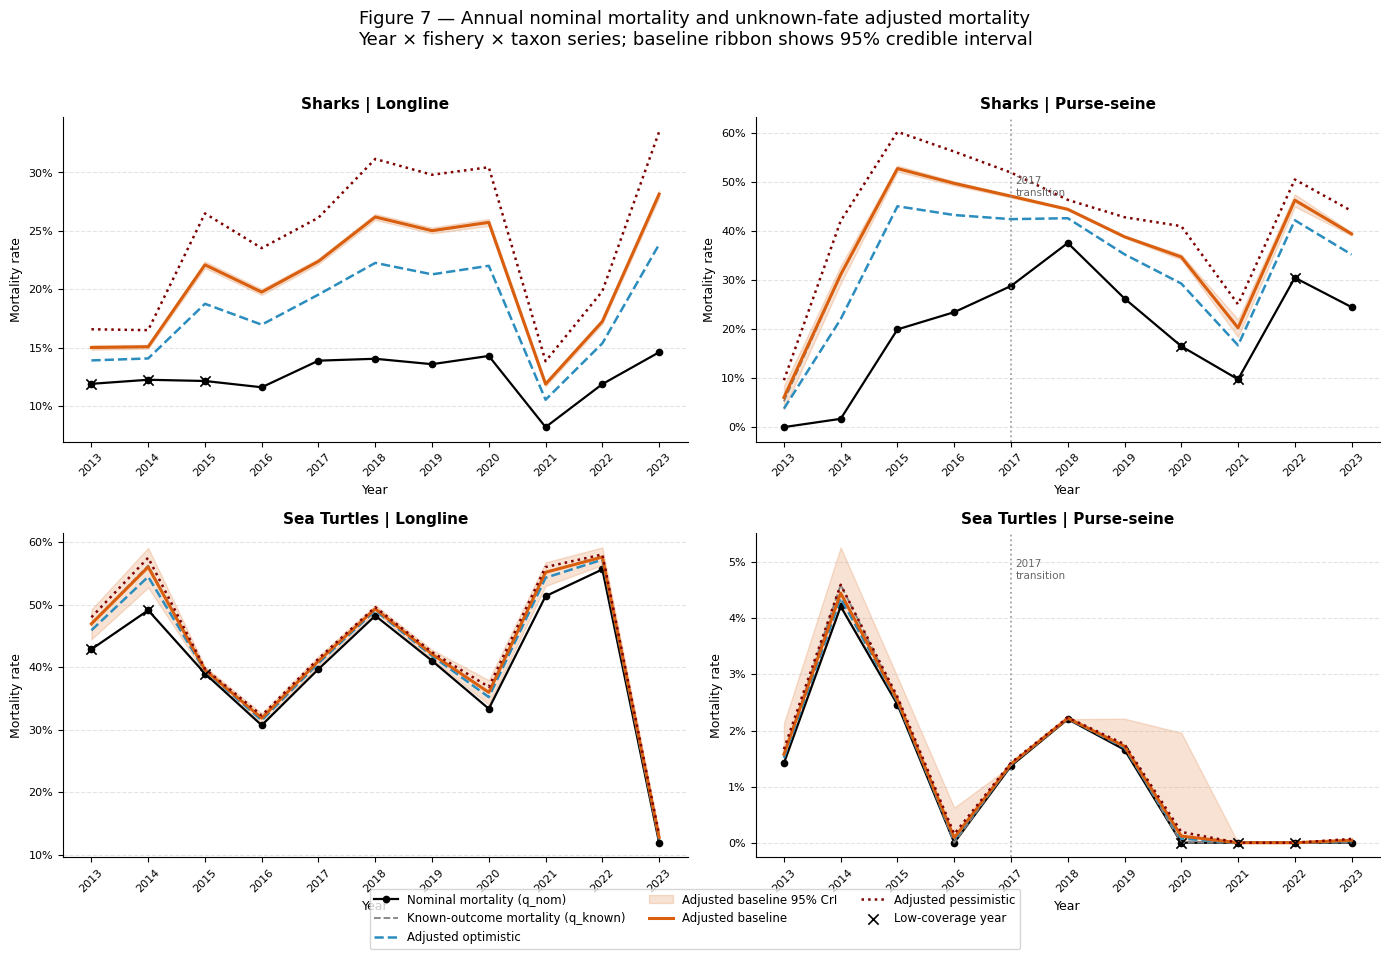

Saved: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/fig7_annual_adjusted_mortality.png


In [8]:
# CELL 8 — Figure 7: annual nominal vs adjusted mortality under three unknown-fate scenarios
scenario_color = {
    'optimistic': '#2b8cbe',
    'baseline': '#d95f0e',
    'pessimistic': '#7f0000'
}

panel_map = [
    ('SHK', 'Longline', 'Sharks | Longline'),
    ('SHK', 'Purse-seine', 'Sharks | Purse-seine'),
    ('TTX', 'Longline', 'Sea Turtles | Longline'),
    ('TTX', 'Purse-seine', 'Sea Turtles | Purse-seine')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (taxon, fishery_label, series_label) in zip(axes, panel_map):
    sub_all = adj_res[
        (adj_res['taxon'] == taxon) &
        (adj_res['fishery_label'] == fishery_label)
    ].copy()

    if sub_all.empty:
        ax.set_visible(False)
        continue

    base = sub_all[sub_all['scenario'] == 'baseline'].sort_values('year')
    opt = sub_all[sub_all['scenario'] == 'optimistic'].sort_values('year')
    pes = sub_all[sub_all['scenario'] == 'pessimistic'].sort_values('year')

    ax.plot(
        base['year'], base['q_nom'],
        color='black', linewidth=1.6, marker='o', markersize=4.5,
        label='Nominal mortality (q_nom)'
    )
    ax.plot(
        base['year'], base['q_known_obs'],
        color='#808080', linewidth=1.3, linestyle='--',
        label='Known-outcome mortality (q_known)'
    )

    ax.plot(
        opt['year'], opt['q_adj_mean'],
        color=scenario_color['optimistic'], linestyle='--',
        linewidth=1.8, label='Adjusted optimistic'
    )
    ax.fill_between(
        base['year'], base['q_adj_hdi_low'], base['q_adj_hdi_high'],
        color=scenario_color['baseline'], alpha=0.18, label='Adjusted baseline 95% CrI'
    )
    ax.plot(
        base['year'], base['q_adj_mean'],
        color=scenario_color['baseline'], linestyle='-',
        linewidth=2.2, label='Adjusted baseline'
    )
    ax.plot(
        pes['year'], pes['q_adj_mean'],
        color=scenario_color['pessimistic'], linestyle=':',
        linewidth=1.8, label='Adjusted pessimistic'
    )

    low_cov = base[base['low_coverage_flag'] == True]
    if len(low_cov) > 0:
        ax.scatter(
            low_cov['year'], low_cov['q_nom'],
            marker='x', s=55, linewidths=1.2, color='black', zorder=6,
            label='Low-coverage year' if (taxon == 'SHK' and fishery_label == 'Longline') else None
        )

    if fishery_label == 'Purse-seine':
        ax.axvline(2017, color='#999999', linestyle=':', linewidth=1.3, alpha=0.9)
        ymax = np.nanmax([
            base['q_adj_hdi_high'].max(),
            base['q_nom'].max(),
            base['q_known_obs'].max()
        ])
        ax.text(2017.08, ymax * 0.96, '2017\ntransition', fontsize=7.5, color='#666666', va='top')

    ax.set_title(series_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Mortality rate', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_xlim(YEAR_MIN - 0.5, YEAR_MAX + 0.5)
    ax.set_xticks(range(YEAR_MIN, YEAR_MAX + 1))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', ncol=3,
    frameon=True, fontsize=8.5,
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    'Figure 7 — Annual nominal mortality and unknown-fate adjusted mortality\n'
    'Year × fishery × taxon series; baseline ribbon shows 95% credible interval',
    fontsize=13, y=1.02
)

plt.tight_layout()
fig7_path = os.path.join(OUTPUT_PATH, 'fig7_annual_adjusted_mortality.png')
plt.savefig(fig7_path, bbox_inches='tight')
plt.show()
print('Saved:', fig7_path)


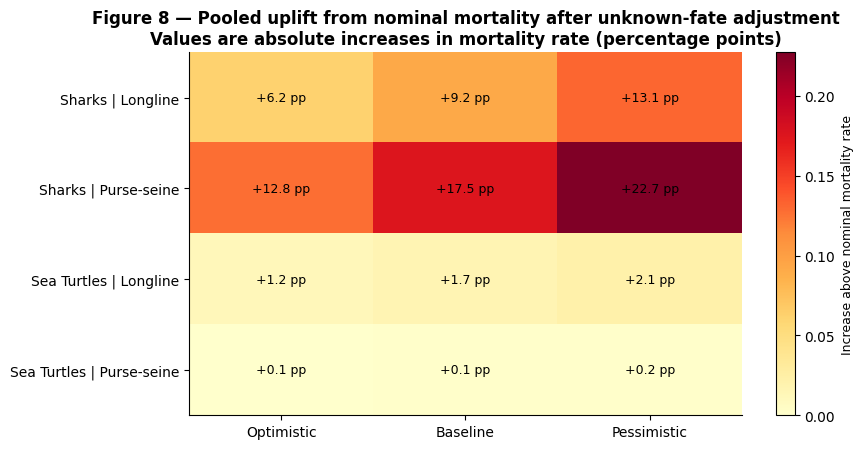

Saved: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/fig8_pooled_uplift_heatmap.png


In [9]:
# CELL 9 — Figure 8: pooled uplift from nominal mortality under unknown-fate scenarios
heat = (
    pooled_res.pivot(index='series_label', columns='scenario', values='uplift_from_nominal')
              .reindex(SERIES_ORDER)
              [['optimistic', 'baseline', 'pessimistic']]
)

fig, ax = plt.subplots(figsize=(9, 4.6))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0)

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(['Optimistic', 'Baseline', 'Pessimistic'], fontsize=10)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=10)
ax.set_title(
    'Figure 8 — Pooled uplift from nominal mortality after unknown-fate adjustment\n'
    'Values are absolute increases in mortality rate (percentage points)',
    fontsize=12, fontweight='bold'
)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if np.isfinite(val):
            ax.text(
                j, i, f'+{val * 100:.1f} pp',
                ha='center', va='center', fontsize=9, color='black'
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Increase above nominal mortality rate', fontsize=9)

plt.tight_layout()
fig8_path = os.path.join(OUTPUT_PATH, 'fig8_pooled_uplift_heatmap.png')
plt.savefig(fig8_path, bbox_inches='tight')
plt.show()
print('Saved:', fig8_path)


## Sensitivity analysis

The goal here is not to prove one specification is “true.” The goal is to show whether the main inference is stable when we vary reasonable modeling choices.

We compare pooled **baseline-scenario** adjusted mortality across:

- `baseline_EB_all`: empirical-Bayes prior, all years
- `flat_all`: flat Beta(1,1) prior, all years
- `EB_excl_lowcov`: empirical-Bayes prior, excluding low-coverage years
- `EB_ps_strict_2018plus`: empirical-Bayes prior, and for purse seine only, years 2018+ (treating 2017 as transition)


In [10]:
# CELL 10 — Sensitivity analysis
def run_sensitivity_setting(series_df, prior_mode='EB', exclude_lowcov=False, strict_ps=False, n_draws=5000):
    sub = series_df.copy()

    if exclude_lowcov and 'low_coverage_flag' in sub.columns:
        sub = sub[~sub['low_coverage_flag']].copy()

    if strict_ps and (sub['fishery_label'].iloc[0] == 'Purse-seine'):
        sub = sub[sub['year'] >= 2018].copy()

    sub = sub.sort_values('year').reset_index(drop=True)

    if len(sub) == 0 or sub['C'].sum() <= 0 or sub['K'].sum() <= 0:
        return None

    if prior_mode == 'flat':
        prior_fit = {
            'alpha': 1.0,
            'beta': 1.0,
            'prior_mean': 0.5,
            'prior_ess': 2.0,
            'method': 'flat'
        }
    else:
        prior_fit = fit_eb_beta_binomial(sub['K'], sub['M'])

    summary_df, p_draws = simulate_known_outcome_posteriors(
        sub=sub,
        alpha_prior=prior_fit['alpha'],
        beta_prior=prior_fit['beta'],
        n_draws=n_draws,
        seed=RANDOM_SEED + 17
    )

    rng_local = np.random.default_rng(RANDOM_SEED + 99)
    pooled_rows = []

    for scenario, delta in SCENARIOS.items():
        total_deaths_draw = np.zeros(p_draws.shape[1], dtype=float)

        for i, row in sub.iterrows():
            p_star = expit(logit(np.clip(p_draws[i], 1e-6, 1 - 1e-6)) + delta)
            unk_deaths = rng_local.binomial(int(row['U']), p_star)
            total_deaths_draw += (int(row['M']) + unk_deaths)

        q_pooled = total_deaths_draw / float(sub['C'].sum())
        lo, hi = hdi_bounds(q_pooled, prob=HDI_PROB)

        pooled_rows.append({
            'scenario': scenario,
            'q_adj_pooled_mean': float(np.mean(q_pooled)),
            'q_adj_pooled_hdi_low': float(lo),
            'q_adj_pooled_hdi_high': float(hi)
        })

    out = pd.DataFrame(pooled_rows)
    out['years_used'] = int(sub['year'].nunique())
    out['total_C'] = int(sub['C'].sum())
    out['total_M'] = int(sub['M'].sum())
    out['total_U'] = int(sub['U'].sum())
    out['prior_mode'] = prior_mode
    out['exclude_lowcov'] = exclude_lowcov
    out['strict_ps'] = strict_ps
    out['prior_method'] = prior_fit['method']
    return out

settings = [
    ('baseline_EB_all', {'prior_mode': 'EB', 'exclude_lowcov': False, 'strict_ps': False}),
    ('flat_all', {'prior_mode': 'flat', 'exclude_lowcov': False, 'strict_ps': False}),
    ('EB_excl_lowcov', {'prior_mode': 'EB', 'exclude_lowcov': True, 'strict_ps': False}),
    ('EB_ps_strict_2018plus', {'prior_mode': 'EB', 'exclude_lowcov': False, 'strict_ps': True})
]

sens_rows = []

for (taxon, fishery_label), sub in annual.groupby(['taxon', 'fishery_label']):
    sub = sub.sort_values('year').reset_index(drop=True).copy()
    series_label = TAXON_LABELS[taxon] + ' | ' + fishery_label

    for setting_name, kwargs in settings:
        out = run_sensitivity_setting(sub, **kwargs)
        if out is None:
            continue
        out['taxon'] = taxon
        out['taxon_label'] = TAXON_LABELS[taxon]
        out['fishery_label'] = fishery_label
        out['series_label'] = series_label
        out['setting'] = setting_name
        sens_rows.append(out)

sens_res = pd.concat(sens_rows, ignore_index=True)

baseline_lookup = (
    sens_res[sens_res['setting'] == 'baseline_EB_all'][['taxon', 'fishery_label', 'scenario', 'q_adj_pooled_mean']]
    .rename(columns={'q_adj_pooled_mean': 'baseline_mean'})
)

sens_res = sens_res.merge(
    baseline_lookup,
    on=['taxon', 'fishery_label', 'scenario'],
    how='left'
)
sens_res['delta_vs_baseline'] = sens_res['q_adj_pooled_mean'] - sens_res['baseline_mean']

print('Sensitivity summary (baseline scenario shown first)')
print(
    sens_res[
        ['series_label', 'setting', 'scenario', 'years_used', 'q_adj_pooled_mean', 'delta_vs_baseline']
    ]
    .round(4)
    .sort_values(['series_label', 'setting', 'scenario'])
    .to_string(index=False)
)


Sensitivity summary (baseline scenario shown first)
             series_label               setting    scenario  years_used  q_adj_pooled_mean  delta_vs_baseline
   Sea Turtles | Longline        EB_excl_lowcov    baseline           8             0.3957            -0.0092
   Sea Turtles | Longline        EB_excl_lowcov  optimistic           8             0.3919            -0.0086
   Sea Turtles | Longline        EB_excl_lowcov pessimistic           8             0.4000            -0.0096
   Sea Turtles | Longline EB_ps_strict_2018plus    baseline          11             0.4049             0.0000
   Sea Turtles | Longline EB_ps_strict_2018plus  optimistic          11             0.4005             0.0000
   Sea Turtles | Longline EB_ps_strict_2018plus pessimistic          11             0.4095             0.0000
   Sea Turtles | Longline       baseline_EB_all    baseline          11             0.4049             0.0000
   Sea Turtles | Longline       baseline_EB_all  optimistic         

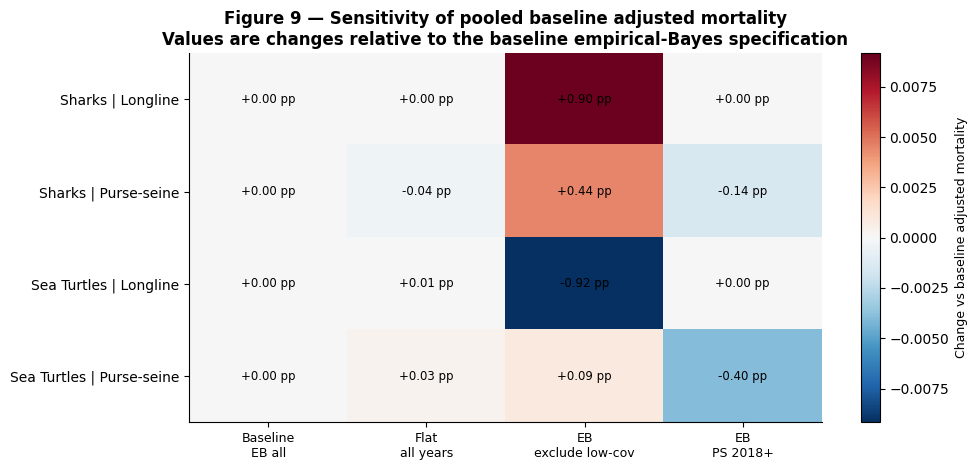

Saved: /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/fig9_sensitivity_heatmap.png


In [11]:
# CELL 11 — Figure 9: sensitivity heatmap for baseline adjusted mortality
heat_sens = (
    sens_res[sens_res['scenario'] == 'baseline']
        .pivot(index='series_label', columns='setting', values='delta_vs_baseline')
        .reindex(SERIES_ORDER)
        [['baseline_EB_all', 'flat_all', 'EB_excl_lowcov', 'EB_ps_strict_2018plus']]
)

fig, ax = plt.subplots(figsize=(10, 4.8))
vmax = np.nanmax(np.abs(heat_sens.values))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 0.001

im = ax.imshow(heat_sens.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(heat_sens.columns)))
ax.set_xticklabels(
    ['Baseline\nEB all', 'Flat\nall years', 'EB\nexclude low-cov', 'EB\nPS 2018+'],
    fontsize=9
)
ax.set_yticks(range(len(heat_sens.index)))
ax.set_yticklabels(heat_sens.index, fontsize=10)
ax.set_title(
    'Figure 9 — Sensitivity of pooled baseline adjusted mortality\n'
    'Values are changes relative to the baseline empirical-Bayes specification',
    fontsize=12, fontweight='bold'
)

for i in range(heat_sens.shape[0]):
    for j in range(heat_sens.shape[1]):
        val = heat_sens.values[i, j]
        if np.isfinite(val):
            ax.text(
                j, i, f'{val * 100:+.2f} pp',
                ha='center', va='center', fontsize=8.5, color='black'
            )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Change vs baseline adjusted mortality', fontsize=9)

plt.tight_layout()
fig9_path = os.path.join(OUTPUT_PATH, 'fig9_sensitivity_heatmap.png')
plt.savefig(fig9_path, bbox_inches='tight')
plt.show()
print('Saved:', fig9_path)


In [12]:
# CELL 12 — Save outputs for manuscript tables and later notebooks
priors_out = os.path.join(OUTPUT_PATH, 'NB3_priors_empirical_bayes.csv')
known_out = os.path.join(OUTPUT_PATH, 'NB3_known_outcome_posterior.csv')
annual_adj_out = os.path.join(OUTPUT_PATH, 'NB3_unknown_fate_adjusted_annual.csv')
pooled_adj_out = os.path.join(OUTPUT_PATH, 'NB3_unknown_fate_adjusted_pooled.csv')
sens_out = os.path.join(OUTPUT_PATH, 'NB3_sensitivity_summary.csv')

priors_df.to_csv(priors_out, index=False)
known_res.to_csv(known_out, index=False)
adj_res.to_csv(annual_adj_out, index=False)
pooled_res.to_csv(pooled_adj_out, index=False)
sens_res.to_csv(sens_out, index=False)

print('Saved files:')
for p in [priors_out, known_out, annual_adj_out, pooled_adj_out, sens_out]:
    print(' -', p)

print('\nHeadline pooled table for manuscript interpretation')
headline = (
    pooled_res[
        ['series_label', 'scenario', 'q_nom_pooled', 'q_known_pooled',
         'q_adj_pooled_mean', 'q_adj_pooled_hdi_low', 'q_adj_pooled_hdi_high',
         'uplift_from_nominal']
    ]
    .copy()
    .round(4)
)
print(headline.to_string(index=False))


Saved files:
 - /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB3_priors_empirical_bayes.csv
 - /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB3_known_outcome_posterior.csv
 - /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB3_unknown_fate_adjusted_annual.csv
 - /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB3_unknown_fate_adjusted_pooled.csv
 - /content/drive/MyDrive/FishStatPj/Paper5TunaByCatch/outputs/NB3_sensitivity_summary.csv

Headline pooled table for manuscript interpretation
             series_label    scenario  q_nom_pooled  q_known_pooled  q_adj_pooled_mean  q_adj_pooled_hdi_low  q_adj_pooled_hdi_high  uplift_from_nominal
        Sharks | Longline    baseline        0.1292          0.2151             0.2211                0.2203                 0.2219               0.0919
        Sharks | Longline  optimistic        0.1292          0.2151             0.1907                0.1901                 0.1914               0.

### What this notebook now gives you

- A defensible **known-outcome shrinkage model** at the annual series level
- Annual and pooled **unknown-fate adjusted mortality** under three scenario assumptions
- Sensitivity checks that match the main methodological risks in the paper
- Clean CSV outputs for manuscript tables and later polishing
